### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *
from src.data.plot import *


load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [3]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- analise_municipio (705.43 KB)
- analise_uf (20.16 KB)
- dim_contexto_socioeconomico_uf (7.79 KB)
- fact_escola (3827.88 KB)
- fact_municipio (100.49 KB)
- fact_uf_ano (25.09 KB)
- ranking_prioridade (966.98 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [4]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")


df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")


# df_fact_escola       = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")
# df_contexto       = carregar_parquet_s3(s3, BUCKET, "dim_contexto_socioeconomico_uf", subpasta="dados_externos")
# df_aux_muni       = carregar_parquet_s3(s3, BUCKET, "fact_municipio", subpasta="dados_externos")
# df_aux_uf       = carregar_parquet_s3(s3, BUCKET, "fact_uf_ano", subpasta="dados_externos")

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [5]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [6]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO','VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


✅ Merge concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO: 3929
Percentual de nulos: 0.06%


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [7]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
    on=['NU_ANO_AVALIACAO', 'CO_UF'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


✅ Merge de Estado concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_UF: 27698
Percentual de nulos: 0.45%


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [8]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [9]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 21


In [10]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

In [11]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'ID_ALUNO', 'ID_ESCOLA',
       'TP_DEPENDENCIA', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026'],
      dtype='str')

In [12]:
colunas = ['NU_ANO_AVALIACAO','CO_UF','TP_DEPENDENCIA','CO_MUNICIPIO','IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','VL_PESO_ALUNO_LP','VL_PROFICIENCIA_LP','IN_ALFABETIZADO','VL_MEDIA_LP_TOTAL_MUNICIPIO','PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF','META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024','META_UF_2025', 'META_UF_2026']

alunos = df_alunos[colunas]

In [13]:
print('percentual de nulo na base')
(alunos.isna().mean() * 100).round(2)

percentual de nulo na base


NU_ANO_AVALIACAO                          0.00
CO_UF                                     0.00
TP_DEPENDENCIA                            0.01
CO_MUNICIPIO                              0.01
IN_PRESENCA_LP                            0.00
IN_PREENCHIMENTO_LP                       0.00
VL_PESO_ALUNO_LP                         12.63
VL_PROFICIENCIA_LP                       12.63
IN_ALFABETIZADO                           0.00
VL_MEDIA_LP_TOTAL_MUNICIPIO               0.06
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO     0.06
VL_MEDIA_LP_TOTAL_UF                      0.45
PC_ALUNO_ALFABETIZADO_TOTAL_UF            0.45
META_MUN_2024                             3.73
META_MUN_2025                             3.18
META_MUN_2026                             2.74
META_UF_2024                              6.00
META_UF_2025                              4.67
META_UF_2026                              4.67
dtype: float64

In [14]:
alunos.describe()

,NU_ANO_AVALIACAO,CO_UF,TP_DEPENDENCIA,CO_MUNICIPIO,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,VL_PESO_ALUNO_LP,VL_PROFICIENCIA_LP,IN_ALFABETIZADO,VL_MEDIA_LP_TOTAL_MUNICIPIO,PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO,VL_MEDIA_LP_TOTAL_UF,PC_ALUNO_ALFABETIZADO_TOTAL_UF,META_MUN_2024,META_MUN_2025,META_MUN_2026,META_UF_2024,META_UF_2025,META_UF_2026
count,6.090791e+06,6.090791e+06,6.090163e+06,6.090163e+06,6.090791e+06,6.090791e+06,5.321266e+06,5.321266e+06,6.090791e+06,6.086862e+06,6.086862e+06,6.063093e+06,6.063093e+06,5.863622e+06,5.897093e+06,5.923665e+06,5.725439e+06,5.806535e+06,5.806535e+06
mean,2.024078e+03,3.214248e+01,2.883173e+00,3.229058e+06,8.743966e-01,8.736576e-01,1.141756e+00,7.502996e+02,5.397631e-01,7.492863e+02,6.099881e+01,7.493189e+02,6.101185e+01,5.917322e+01,6.302460e+01,6.688802e+01,5.929319e+01,6.316182e+01,6.701798e+01
std,8.035862e-01,1.027053e+01,3.212269e-01,1.029062e+06,3.314019e-01,3.322349e-01,2.977648e-01,4.780739e+01,4.984164e-01,1.945618e+01,1.533634e+01,1.478920e+01,1.138480e+01,1.257973e+01,1.033914e+01,7.984692e+00,8.007860e+00,6.459540e+00,4.960513e+00
min,2.023000e+03,1.100000e+01,2.000000e+00,1.100015e+06,0.000000e+00,0.000000e+00,9.523810e-02,5.723559e+02,0.000000e+00,6.732983e+02,4.400000e+00,7.131336e+02,3.130000e+01,7.936728e+00,1.400000e+01,2.365000e+01,3.800000e+01,4.590000e+01,5.360000e+01
25%,2.023000e+03,2.600000e+01,3.000000e+00,2.601607e+06,1.000000e+00,1.000000e+00,1.030296e+00,7.226900e+02,0.000000e+00,7.376458e+02,5.137000e+01,7.389000e+02,5.525000e+01,5.000000e+01,5.575829e+01,6.120856e+01,5.660000e+01,6.100000e+01,6.500000e+01
50%,2.024000e+03,3.200000e+01,3.000000e+00,3.205002e+06,1.000000e+00,1.000000e+00,1.095238e+00,7.561461e+02,1.000000e+00,7.473454e+02,6.022000e+01,7.474522e+02,6.001000e+01,5.985000e+01,6.355000e+01,6.704000e+01,5.700000e+01,6.150000e+01,6.600000e+01
75%,2.025000e+03,4.100000e+01,3.000000e+00,4.106902e+06,1.000000e+00,1.000000e+00,1.200000e+00,7.820100e+02,1.000000e+00,7.578920e+02,7.092000e+01,7.572146e+02,7.042000e+01,6.822000e+01,7.043000e+01,7.254431e+01,6.450000e+01,6.700000e+01,7.000000e+01
max,2.025000e+03,5.300000e+01,4.000000e+00,5.300108e+06,1.000000e+00,1.000000e+00,1.425454e+02,9.043820e+02,1.000000e+00,8.712643e+02,1.000000e+02,7.972900e+02,8.531000e+01,8.000000e+01,8.000000e+01,8.000000e+01,7.420000e+01,7.520000e+01,7.620000e+01


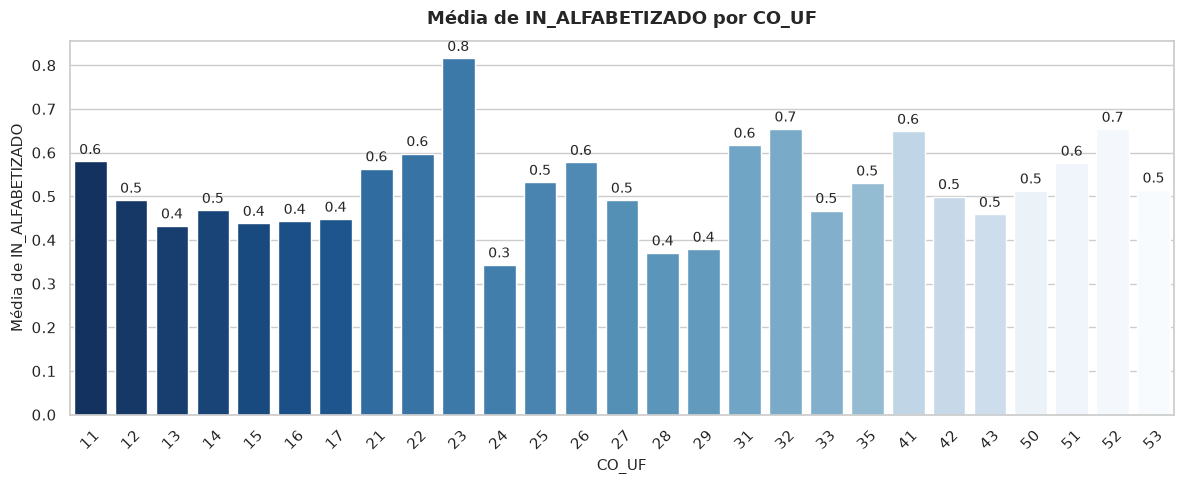

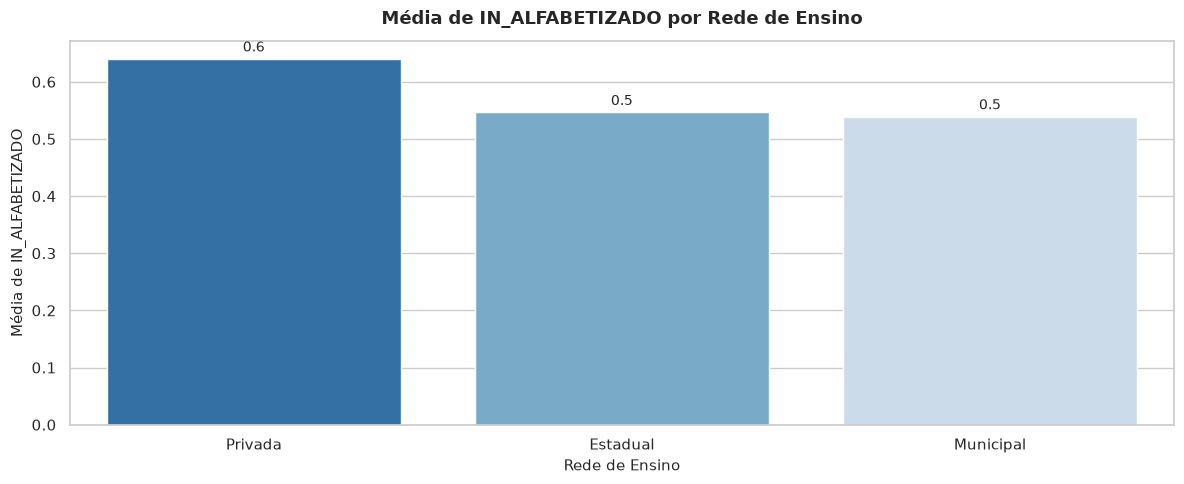

In [15]:
gerar_barplot_medias(df=alunos, x='CO_UF', y='IN_ALFABETIZADO', salvar=False)
gerar_barplot_medias(df=alunos, x='TP_DEPENDENCIA', y='IN_ALFABETIZADO', salvar=False)

📊 Gráfico salvo em: C:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\reports\figures\kde_IN_ALFABETIZADO_por_TP_DEPENDENCIA.png


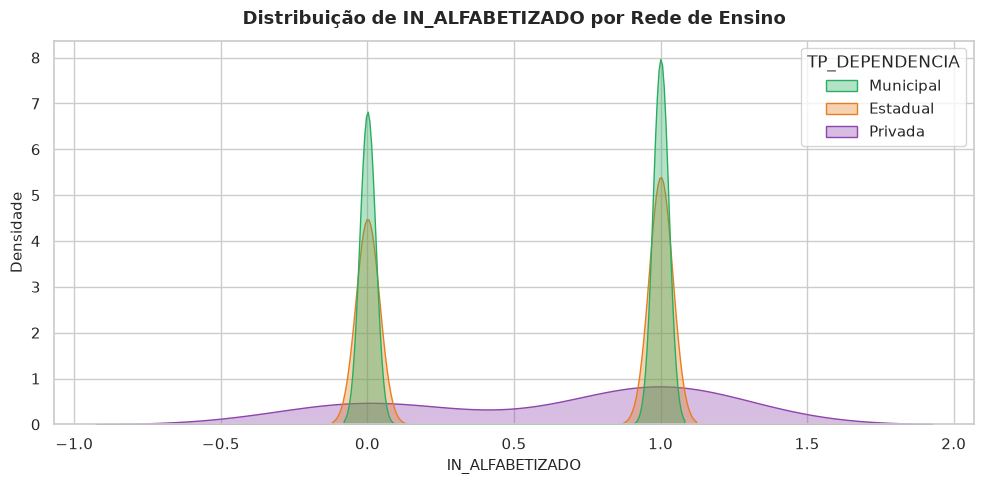

In [16]:
gerar_kdeplot(alunos,x='IN_ALFABETIZADO')

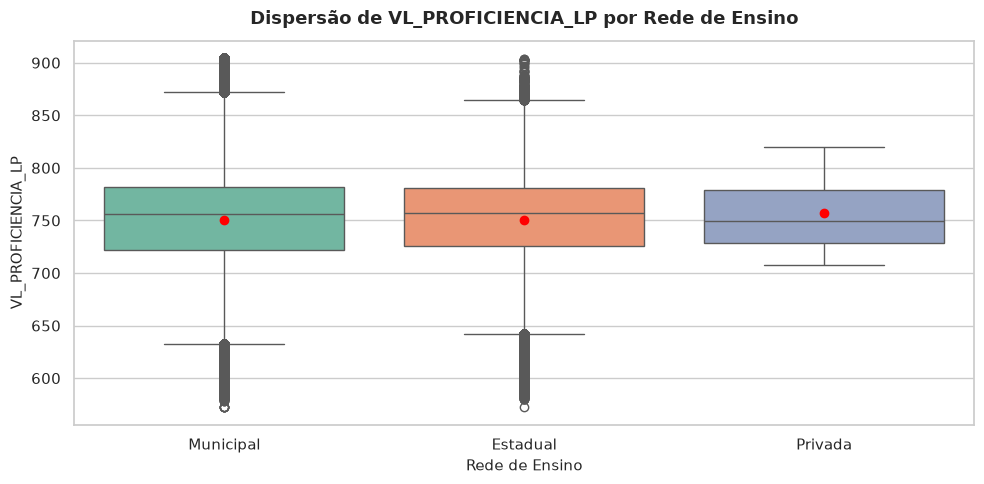

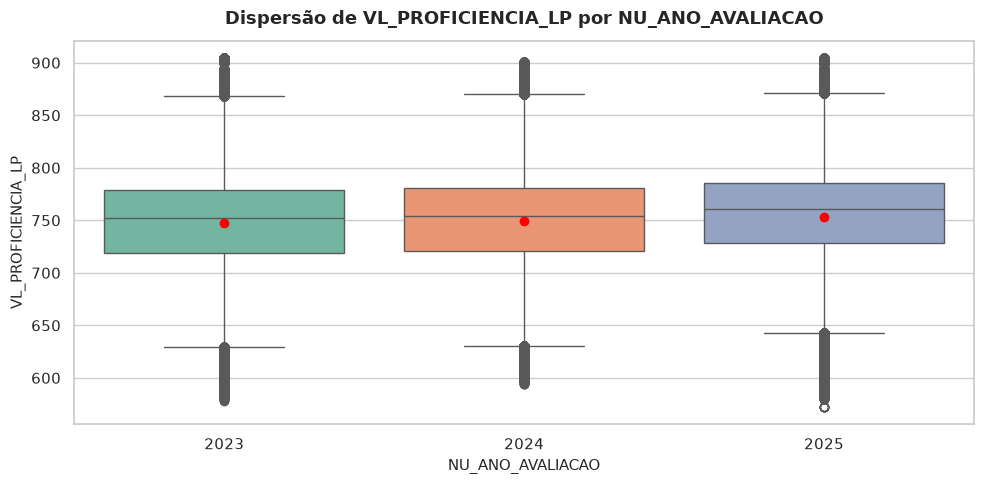

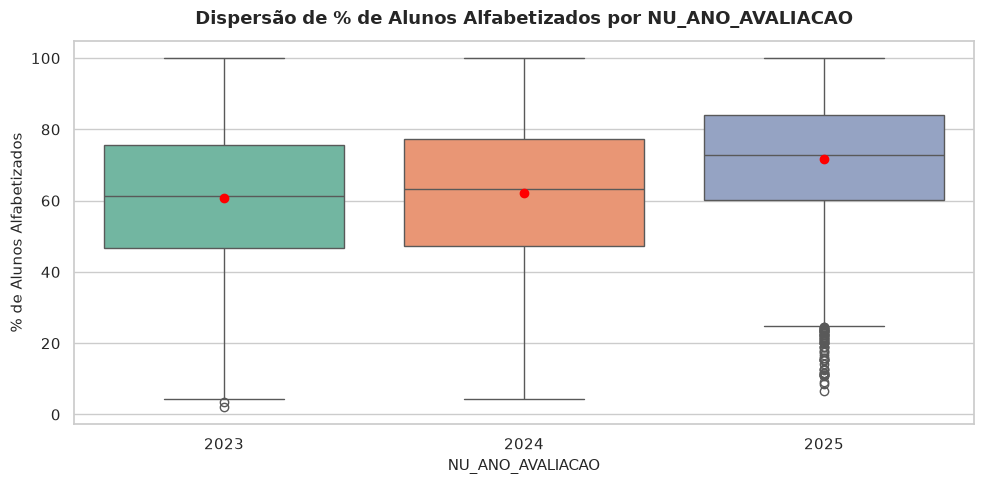

In [17]:
gerar_boxplot(df=alunos, x='TP_DEPENDENCIA', y='VL_PROFICIENCIA_LP', salvar=False)

gerar_boxplot(df=alunos, x='NU_ANO_AVALIACAO', y='VL_PROFICIENCIA_LP', salvar=False)

gerar_boxplot(df=df_municipios, x='NU_ANO_AVALIACAO', y='PC_ALUNO_ALFABETIZADO', salvar=False)


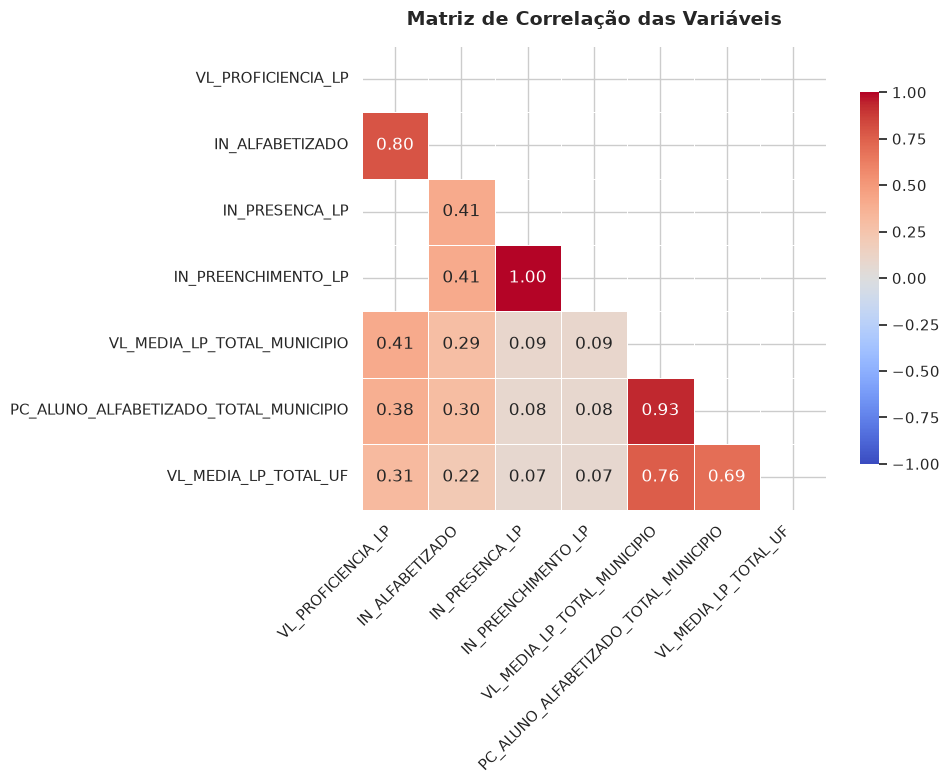

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# 1. Selecione as colunas numéricas de interesse do seu dataset
colunas_interesse = [
    'VL_PROFICIENCIA_LP',
    'IN_ALFABETIZADO',
    'IN_PRESENCA_LP',
    'IN_PREENCHIMENTO_LP',
    'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
    'VL_MEDIA_LP_TOTAL_UF',


]

# Filtra apenas as que realmente existem no seu DataFrame
cols_validas = [c for c in colunas_interesse if c in alunos.columns]

# 2. Calcula a matriz de correlação (Pearson)
corr = alunos[cols_validas].corr()

# 3. Cria máscara para ocultar a metade superior duplicada
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Plota o Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",           # Cores: Azul (negativo) -> Branco (neutro) -> Vermelho (positivo)
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,                # Mostra o número dentro do quadrado
    fmt=".2f",                 # 2 casas decimais
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Matriz de Correlação das Variáveis", fontsize=14, weight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


alfabetização por estado

In [19]:
ranking_uf = alunos.groupby('CO_UF')['IN_ALFABETIZADO'].agg(
    total_alunos='count',
    taxa_alfabetizacao=lambda x: (x.mean() * 100).round(2)
).sort_values(by='taxa_alfabetizacao', ascending=False).reset_index()

print("Top 5 Estados com Maior Alfabetização:")
display(ranking_uf.head(5))

print("\nTop 5 Estados com Menor Alfabetização:")
display(ranking_uf.tail(5))


Top 5 Estados com Maior Alfabetização:


,CO_UF,total_alunos,taxa_alfabetizacao
0,23,284256,81.54
1,32,146985,65.40
2,52,242082,65.32
3,41,419004,64.85
4,31,631406,61.69



Top 5 Estados com Menor Alfabetização:


,CO_UF,total_alunos,taxa_alfabetizacao
22,15,308633,43.79
23,13,179859,43.21
24,29,390767,37.86
25,28,59960,37.04
26,24,91784,34.29


C:\Users\deth_\AppData\Local\Temp\ipykernel_12456\3156627624.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


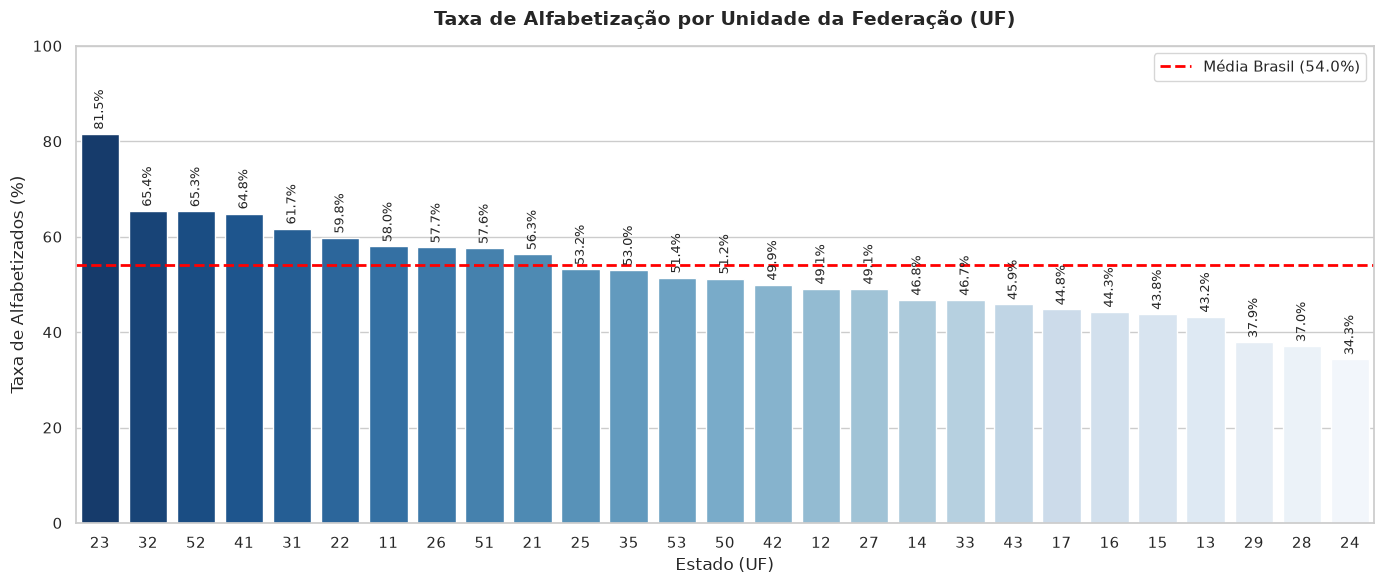

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))

# Ordena os estados pela taxa de alfabetização
ordem = ranking_uf['CO_UF']

sns.barplot(
    data=ranking_uf,
    x='CO_UF',
    y='taxa_alfabetizacao',
    order=ordem,
    palette='Blues_r',
    ax=ax
)

# Linha da média nacional do Brasil
media_brasil = alunos['IN_ALFABETIZADO'].mean() * 100
ax.axhline(media_brasil, color='red', linestyle='--', linewidth=2, label=f'Média Brasil ({media_brasil:.1f}%)')

ax.set_title('Taxa de Alfabetização por Unidade da Federação (UF)', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Estado (UF)', fontsize=12)
ax.set_ylabel('Taxa de Alfabetizados (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(loc='upper right')

# Rótulo com o percentual em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}%',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points', rotation=90)

plt.show()


In [21]:
from scipy.stats import chi2_contingency
import numpy as np

# Tabela de contingência (UF x Alfabetizado)
tabela_crosstab = pd.crosstab(alunos['CO_UF'], alunos['IN_ALFABETIZADO'])

# Teste Qui-Quadrado
chi2, p_valor, dof, _ = chi2_contingency(tabela_crosstab)

# Coeficiente V de Cramér (Força da associação de 0 a 1)
n = tabela_crosstab.sum().sum()
min_dim = min(tabela_crosstab.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))

print(f"📊 Teste Qui-Quadrado: chi2 = {chi2:.2f}, p-valor = {p_valor:.4e}")
print(f"📈 Força da Associação (V de Cramér): {cramer_v:.4f}")

if p_valor < 0.05:
    print("✅ Há dependência estatística significativa entre a UF e a alfabetização do aluno!")


📊 Teste Qui-Quadrado: chi2 = 256845.18, p-valor = 0.0000e+00
📈 Força da Associação (V de Cramér): 0.2054
✅ Há dependência estatística significativa entre a UF e a alfabetização do aluno!


# <font color="green"> Dados Externos </font>

Carregar Dicionario 

In [22]:
pasta_atual = Path().resolve()
path_dicionario_externo = pasta_atual.parent / 'docs' / 'DICIONÁRIO_DADOS_EXTERNOS.xlsx'

dicionario_fact_escola = pd.read_excel(path_dicionario_externo,sheet_name='fact_escola')
dicionario_fact_município = pd.read_excel(path_dicionario_externo,sheet_name='fact_município')
dicionario_fact_uf_ano = pd.read_excel(path_dicionario_externo,sheet_name='fact_uf_ano')


#Manter apenas as variaveis importantes
dicionario_fact_escola =  dicionario_fact_escola[dicionario_fact_escola['MANTER/EXCLUIR']== "MANTER"]
dicionario_fact_município =  dicionario_fact_município[dicionario_fact_município['MANTER/EXCLUIR'] == "MANTER"]
dicionario_fact_uf_ano =  dicionario_fact_uf_ano[dicionario_fact_uf_ano['MANTER/EXCLUIR'] == "MANTER"]
dicionario = pd.concat([dicionario_fact_escola,dicionario_fact_município,dicionario_fact_uf_ano])

#renomear a coluna 1
dicionario = dicionario.rename(
    columns={'NOME DA VARIÁVEL':'VARIAVEL'}
)


In [23]:
df_fact_escola       = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")

colunas_desejadas = dicionario[dicionario['Tabela'] == 'fact_escola']['VARIAVEL'].dropna().tolist()
df_fact_escola = df_fact_escola[colunas_desejadas]

Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


In [24]:
df_aux_muni       = carregar_parquet_s3(s3, BUCKET, "fact_municipio", subpasta="dados_externos")

colunas_desejadas = dicionario[dicionario['Tabela'] == 'fact_município']['VARIAVEL'].dropna().tolist()
df_aux_muni = df_aux_muni[colunas_desejadas]

Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet


In [25]:
df_aux_uf      = carregar_parquet_s3(s3, BUCKET, "fact_uf_ano", subpasta="dados_externos")

colunas_desejadas = dicionario[dicionario['Tabela'] == 'fact_uf_ano']['VARIAVEL'].dropna().tolist()
df_aux_uf = df_aux_uf[colunas_desejadas]

Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_uf_ano.parquet


Join com as tabelas auxiliares externas

In [26]:
""" 
#   df_alunos        → microdados SAEB por aluno
#   df_fact_escola   → fact_escola  filtrada pelo dicionário
#   df_aux_muni      → fact_município filtrada pelo dicionário
#   df_aux_uf        → fact_uf_NU_ANO_AVALIACAO  filtrada pelo dicionário
"""

# ── STEP 0: Padronizar tipos das chaves ──────────────────────────────────────
df_alunos["ID_ESCOLA"]    = pd.to_numeric(df_alunos["ID_ESCOLA"],    errors="coerce")
df_alunos["CO_MUNICIPIO"] = pd.to_numeric(df_alunos["CO_MUNICIPIO"], errors="coerce")
df_alunos["CO_UF"]        = pd.to_numeric(df_alunos["CO_UF"],        errors="coerce")
df_alunos["NU_ANO_AVALIACAO"]          = pd.to_numeric(df_alunos["NU_ANO_AVALIACAO"],          errors="coerce")



if "CO_ENTIDADE" in df_fact_escola.columns:
    df_fact_escola["CO_ENTIDADE"] = pd.to_numeric(df_fact_escola["CO_ENTIDADE"], errors="coerce")
if "NU_ANO_AVALIACAO" in df_fact_escola.columns:
    df_fact_escola["NU_ANO_AVALIACAO"] = pd.to_numeric(df_fact_escola["NU_ANO_AVALIACAO"], errors="coerce")

if "CO_MUNICIPIO" in df_aux_muni.columns:
    df_aux_muni["CO_MUNICIPIO"] = pd.to_numeric(df_aux_muni["CO_MUNICIPIO"], errors="coerce")
if "COD_UF" in df_aux_muni.columns:
    df_aux_muni["COD_UF"] = pd.to_numeric(df_aux_muni["COD_UF"], errors="coerce")

if "NU_ANO_AVALIACAO" in df_aux_uf.columns:
    df_aux_uf["NU_ANO_AVALIACAO"] = pd.to_numeric(df_aux_uf["NU_ANO_AVALIACAO"], errors="coerce")

linhas_antes = len(df_alunos)
cols_antes   = df_alunos.shape[1]
print(f"Linhas antes dos joins : {linhas_antes:,}")
print(f"Colunas antes dos joins: {cols_antes}")



Linhas antes dos joins : 6,090,791
Colunas antes dos joins: 21


In [27]:

# ── JOIN 2: fact_município  (CO_MUNICIPIO + CO_UF) ───────────────────────────
cols_antes_2 = df_alunos.shape[1]
muni_prep    = df_aux_muni.rename(columns={"COD_UF": "CO_UF"}).copy()

join_keys_2  = ["CO_MUNICIPIO", "CO_UF"]
cols_novas_2 = [c for c in muni_prep.columns if c not in df_alunos.columns or c in join_keys_2]
muni_prep    = muni_prep[cols_novas_2].drop_duplicates(subset=join_keys_2)

df_alunos = df_alunos.merge(muni_prep, on=join_keys_2, how="left", validate="m:1")

n2 = df_alunos["CATEGORIA_RISCO_MUNICIPIO"].notna().sum() if "CATEGORIA_RISCO_MUNICIPIO" in df_alunos.columns else 0
print(f"\n✅ JOIN 2 — fact_município")
print(f"   Match: {n2:,} / {linhas_antes:,} ({n2/linhas_antes:.1%})")
print(f"   Colunas adicionadas: {df_alunos.shape[1] - cols_antes_2}")


✅ JOIN 2 — fact_município
   Match: 6,056,228 / 6,090,791 (99.4%)
   Colunas adicionadas: 12


In [28]:
# ── STEP PRÉVIO: Criar SG_UF no df_alunos via CO_UF (se ainda não existir) ───
mapa_uf = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL", 28: "SE", 29: "BA",
    31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS",
    50: "MS", 51: "MT", 52: "GO", 53: "DF"
}

if "SG_UF" not in df_alunos.columns:
    df_alunos["SG_UF"] = df_alunos["CO_UF"].map(mapa_uf)

# Garante que ANO existe no df_alunos (se estiver como NU_ANO_AVALIACAO)
if "ANO" not in df_alunos.columns and "NU_ANO_AVALIACAO" in df_alunos.columns:
    df_alunos["ANO"] = df_alunos["NU_ANO_AVALIACAO"]


# ── JOIN 3: fact_uf_ano  (SG_UF + ANO) ──────────────────────────────────────
cols_antes_3 = df_alunos.shape[1]
uf_prep      = df_aux_uf.copy()

join_keys_3  = ["SG_UF", "ANO"]
cols_novas_3 = [c for c in uf_prep.columns if c not in df_alunos.columns or c in join_keys_3]
uf_prep      = uf_prep[cols_novas_3].drop_duplicates(subset=join_keys_3)

df_alunos = df_alunos.merge(uf_prep, on=join_keys_3, how="left", validate="m:1")

n3 = df_alunos["TAXA_ANALFABETISMO_PCT"].notna().sum() if "TAXA_ANALFABETISMO_PCT" in df_alunos.columns else 0
print(f"\n✅ JOIN 3 — fact_uf_ano")
print(f"   Match: {n3:,} / {linhas_antes:,} ({n3/linhas_antes:.1%})")
print(f"   Colunas adicionadas: {df_alunos.shape[1] - cols_antes_3}")



✅ JOIN 3 — fact_uf_ano
   Match: 6,090,163 / 6,090,791 (100.0%)
   Colunas adicionadas: 5


In [29]:
# ── DIAGNÓSTICO FINAL ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("DIAGNÓSTICO PÓS-MERGE")
print("="*60)

assert len(df_alunos) == linhas_antes, (
    f"⚠️ ERRO: linhas mudaram! Esperado {linhas_antes}, obtido {len(df_alunos)}. "
    "Verifique duplicatas nas tabelas externas."
)

print(f"✅ Linhas preservadas : {len(df_alunos):,}")
print(f"✅ Colunas totais     : {df_alunos.shape[1]}")
print(f"✅ Colunas adicionadas: {df_alunos.shape[1] - cols_antes}")

cols_externas = [
    "COD_RISCO_ESCOLA", "CATEGORIA_RISCO_ESCOLA", "NIVEL_RISCO_DESC_ESCOLA",
    "DESC_IMPACTO_ESCOLA", "QT_MATRICULA_2ANO_EF",
    "COD_RISCO_MUNICIPIO", "CATEGORIA_RISCO_MUNICIPIO", "NIVEL_RISCO_DESC_MUNICIPIO",
    "COD_RISCO_UF", "CATEGORIA_RISCO_UF",
    "TAXA_ANALFABETISMO_PCT", "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO", "TAXA_FREQ_LIQUIDA_FUND_PCT", "POPULACAO_MIL",
    "FUN_02_CAT_0", 
]

print("\n📊 Taxa de preenchimento das variáveis externas:")
for col in cols_externas:
    if col in df_alunos.columns:
        pct = df_alunos[col].notna().mean()
        icone = "✅" if pct > 0.8 else ("⚠️" if pct > 0.3 else "❌")
        print(f"   {icone} {col:<45} {pct:.1%}")
    else:
        print(f"   ⛔ {col:<45} NÃO ENCONTRADA")



DIAGNÓSTICO PÓS-MERGE
✅ Linhas preservadas : 6,090,791
✅ Colunas totais     : 39
✅ Colunas adicionadas: 18

📊 Taxa de preenchimento das variáveis externas:
   ⛔ COD_RISCO_ESCOLA                              NÃO ENCONTRADA
   ⛔ CATEGORIA_RISCO_ESCOLA                        NÃO ENCONTRADA
   ⛔ NIVEL_RISCO_DESC_ESCOLA                       NÃO ENCONTRADA
   ⛔ DESC_IMPACTO_ESCOLA                           NÃO ENCONTRADA
   ⛔ QT_MATRICULA_2ANO_EF                          NÃO ENCONTRADA
   ✅ COD_RISCO_MUNICIPIO                           99.4%
   ✅ CATEGORIA_RISCO_MUNICIPIO                     99.4%
   ✅ NIVEL_RISCO_DESC_MUNICIPIO                    99.4%
   ✅ COD_RISCO_UF                                  100.0%
   ✅ CATEGORIA_RISCO_UF                            100.0%
   ✅ TAXA_ANALFABETISMO_PCT                        100.0%
   ✅ RENDIMENTO_MEDIO_MENSAL_REAIS                 100.0%
   ✅ RENDA_PERCAPITA_SBENEF_MEDIO                  100.0%
   ❌ TAXA_FREQ_LIQUIDA_FUND_PCT                    0

In [30]:
cols_ffill = ["RENDA_PERCAPITA_SBENEF_MEDIO", "TAXA_FREQ_LIQUIDA_FUND_PCT"]

# Constrói pivot por UF: pega o valor de 2024 e aplica em 2025 quando NaN
ref_2024 = (
    df_aux_uf[df_aux_uf["ANO"] == 2024][["SG_UF"] + cols_ffill]
    .rename(columns={c: f"{c}_2024" for c in cols_ffill})
)

df_alunos = df_alunos.merge(ref_2024, on="SG_UF", how="left")

for col in cols_ffill:
    mask_nulo = df_alunos[col].isna()
    df_alunos.loc[mask_nulo, col] = df_alunos.loc[mask_nulo, f"{col}_2024"]
    df_alunos.drop(columns=[f"{col}_2024"], inplace=True)

# Validar
for col in cols_ffill:
    pct_nulo = df_alunos[col].isna().mean()
    print(f"   {col}: {pct_nulo:.1%} NaN restante")

   RENDA_PERCAPITA_SBENEF_MEDIO: 0.0% NaN restante
   TAXA_FREQ_LIQUIDA_FUND_PCT: 100.0% NaN restante


In [31]:
print("Taxa de preenchimento das variáveis externas:")
for col in cols_externas:
    if col in df_alunos.columns:
        pct = df_alunos[col].notna().mean()
        icone = "OKAY : " if pct > 0.8 else ("⚠️" if pct > 0.3 else "ATENÇÃO : ")
        print(f"   {icone} {col:<45} {pct:.1%}")
    else:
        print(f"  {col:<45} NÃO ENCONTRADA")


Taxa de preenchimento das variáveis externas:
  COD_RISCO_ESCOLA                              NÃO ENCONTRADA
  CATEGORIA_RISCO_ESCOLA                        NÃO ENCONTRADA
  NIVEL_RISCO_DESC_ESCOLA                       NÃO ENCONTRADA
  DESC_IMPACTO_ESCOLA                           NÃO ENCONTRADA
  QT_MATRICULA_2ANO_EF                          NÃO ENCONTRADA
   OKAY :  COD_RISCO_MUNICIPIO                           99.4%
   OKAY :  CATEGORIA_RISCO_MUNICIPIO                     99.4%
   OKAY :  NIVEL_RISCO_DESC_MUNICIPIO                    99.4%
   OKAY :  COD_RISCO_UF                                  100.0%
   OKAY :  CATEGORIA_RISCO_UF                            100.0%
   OKAY :  TAXA_ANALFABETISMO_PCT                        100.0%
   OKAY :  RENDIMENTO_MEDIO_MENSAL_REAIS                 100.0%
   OKAY :  RENDA_PERCAPITA_SBENEF_MEDIO                  100.0%
   ATENÇÃO :  TAXA_FREQ_LIQUIDA_FUND_PCT                    0.0%
   OKAY :  POPULACAO_MIL                                 100.0%
 

Remover colunas que tem mais de 10% dos dados nulos 

In [32]:
# ── Tabela de Regiões do Brasil ───────────────────────────────────────────────
mapa_regioes = {
    # Norte
    "AM": "Norte", "RR": "Norte", "AP": "Norte", "PA": "Norte",
    "TO": "Norte", "RO": "Norte", "AC": "Norte",
    # Nordeste
    "MA": "Nordeste", "PI": "Nordeste", "CE": "Nordeste", "RN": "Nordeste",
    "PE": "Nordeste", "PB": "Nordeste", "SE": "Nordeste", "AL": "Nordeste",
    "BA": "Nordeste",
    # Centro-Oeste
    "MT": "Centro-Oeste", "MS": "Centro-Oeste", "GO": "Centro-Oeste",
    "DF": "Centro-Oeste",
    # Sudeste
    "SP": "Sudeste", "RJ": "Sudeste", "MG": "Sudeste", "ES": "Sudeste",
    # Sul
    "PR": "Sul", "SC": "Sul", "RS": "Sul",
}

df_alunos["REGIAO"] = df_alunos["SG_UF"].map(mapa_regioes)

# Verificação
print(df_alunos.groupby("REGIAO")["ID_ALUNO"].count().sort_values(ascending=False))


REGIAO
Sudeste         2142126
Nordeste        1618878
Sul             1055058
Norte            695471
Centro-Oeste     579258
Name: ID_ALUNO, dtype: int64


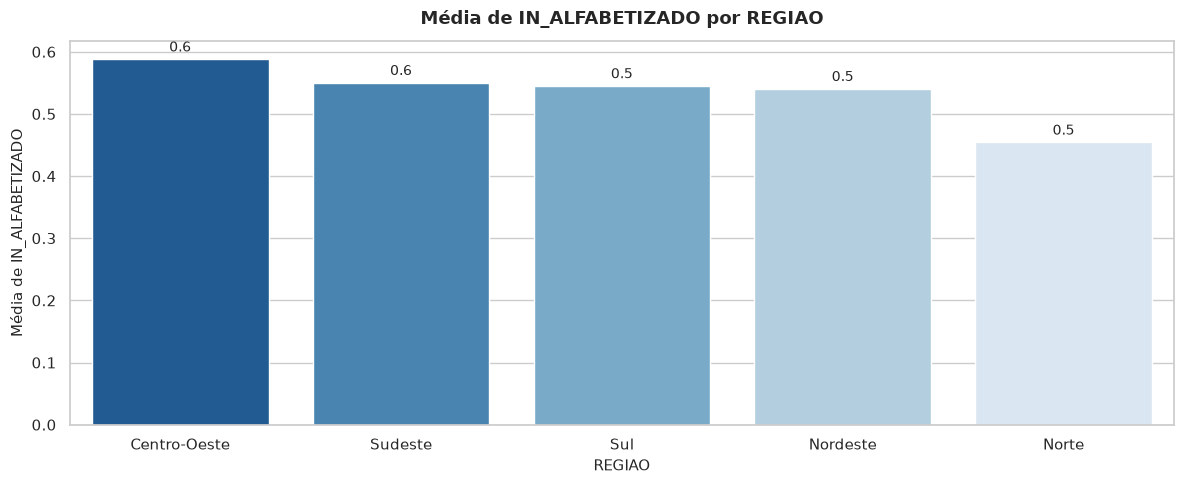

In [33]:
gerar_barplot_medias(df=df_alunos, x='REGIAO', y='IN_ALFABETIZADO', salvar=False)

In [34]:
anos = df_alunos["ANO"]

df_alunos["META_MUN"] = np.select(
    [anos == 2023, anos == 2024, anos == 2025, anos == 2026],
    [df_alunos["META_MUN_2024"],   # 2023 → meta do ano seguinte
     df_alunos["META_MUN_2024"],
     df_alunos["META_MUN_2025"],
     df_alunos["META_MUN_2026"]],
    default=np.nan
)

df_alunos["META_UF"] = np.select(
    [anos == 2023, anos == 2024, anos == 2025, anos == 2026],
    [df_alunos["META_UF_2024"],
     df_alunos["META_UF_2024"],
     df_alunos["META_UF_2025"],
     df_alunos["META_UF_2026"]],
    default=np.nan
)


In [35]:
# 1. Salva o mapeamento CO_UF → SG_UF + REGIAO (para consultas futuras)
df_mapa_uf = (
    df_alunos[["CO_UF", "SG_UF", "REGIAO"]]
    .drop_duplicates()
    .sort_values("CO_UF")
    .reset_index(drop=True)
)
print(df_mapa_uf)


    CO_UF SG_UF        REGIAO
0      11    RO         Norte
1      12    AC         Norte
2      13    AM         Norte
3      14    RR         Norte
4      15    PA         Norte
5      16    AP         Norte
6      17    TO         Norte
7      21    MA      Nordeste
8      22    PI      Nordeste
9      23    CE      Nordeste
10     24    RN      Nordeste
11     25    PB      Nordeste
12     26    PE      Nordeste
13     27    AL      Nordeste
14     28    SE      Nordeste
15     29    BA      Nordeste
16     31    MG       Sudeste
17     32    ES       Sudeste
18     33    RJ       Sudeste
19     35    SP       Sudeste
20     41    PR           Sul
21     42    SC           Sul
22     43    RS           Sul
23     50    MS  Centro-Oeste
24     51    MT  Centro-Oeste
25     52    GO  Centro-Oeste
26     53    DF  Centro-Oeste


In [36]:
# # 1. Salva o mapeamento CO_UF → SG_UF + REGIAO (para consultas futuras)
# df_cod_municipio = (
#     df_alunos[["CO_MUNICIPIO", "NO_MUNICIPIO", "SG_UF"]]
#     .drop_duplicates()
#     .sort_values("CO_MUNICIPIO")
#     .reset_index(drop=True)
# )
# print(df_cod_municipio)


In [37]:
# Correlação de todas as numéricas com IN_ALFABETIZADO

corr_target = (
    df_alunos.select_dtypes(include='number')
    .corr(numeric_only=True)["IN_ALFABETIZADO"]
    .drop("IN_ALFABETIZADO")          # remove a autocorrelação (1.0)
    .sort_values(ascending=False)
)

print(corr_target.to_string())


VL_PROFICIENCIA_LP                       0.795725
IN_PREENCHIMENTO_LP                      0.411827
IN_PRESENCA_LP                           0.410447
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO    0.303204
VL_MEDIA_LP_TOTAL_MUNICIPIO              0.292401
META_MUN_2025                            0.224418
META_MUN_2026                            0.223974
META_MUN                                 0.223892
META_MUN_2024                            0.223892
PC_ALUNO_ALFABETIZADO_TOTAL_UF           0.223752
VL_MEDIA_LP_TOTAL_UF                     0.218196
META_UF_2026                             0.135336
META_UF                                  0.135278
META_UF_2024                             0.135269
META_UF_2025                             0.134179
FUN_02_CAT_0                             0.079080
COD_RISCO_MUNICIPIO                      0.069700
NU_ANO_AVALIACAO                         0.069290
CO_MUNICIPIO                             0.032128
CO_UF                                    0.031903


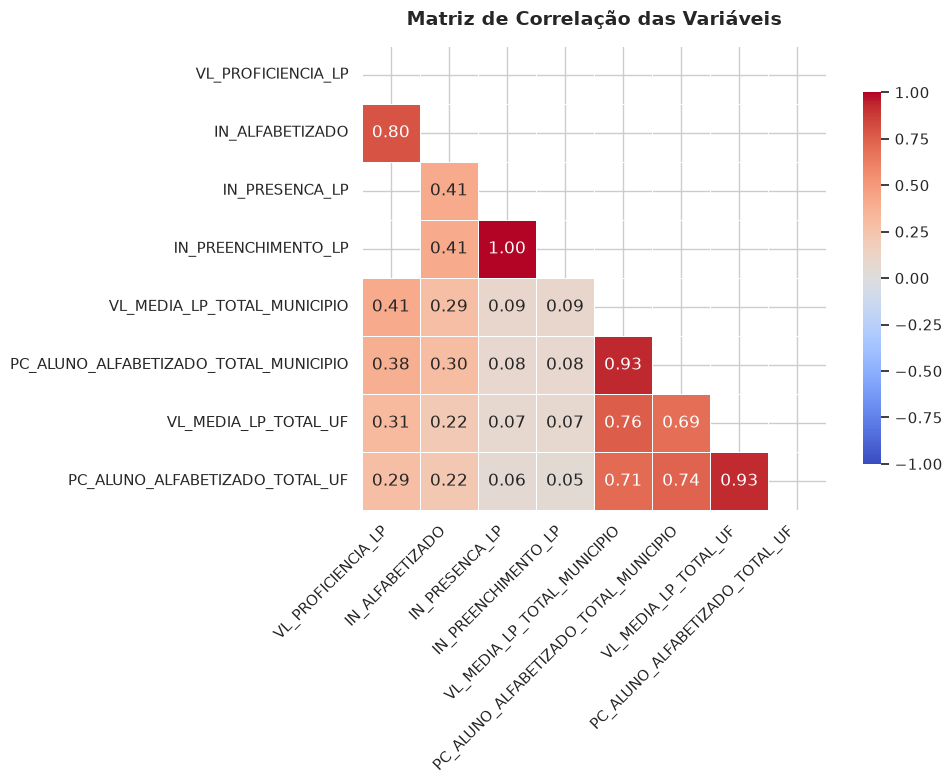

In [38]:
# 1. Selecione as colunas numéricas de interesse do seu dataset

colunas_interesse = [
    'VL_PROFICIENCIA_LP',
    'IN_ALFABETIZADO',
    'IN_PRESENCA_LP',
    'IN_PREENCHIMENTO_LP',
    'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
    'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
]

# Filtra apenas as que realmente existem no seu DataFrame
cols_validas = [c for c in colunas_interesse if c in alunos.columns]

# 2. Calcula a matriz de correlação (Pearson)
corr = alunos[cols_validas].corr()

# 3. Cria máscara para ocultar a metade superior duplicada
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Plota o Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",           # Cores: Azul (negativo) -> Branco (neutro) -> Vermelho (positivo)
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,                # Mostra o número dentro do quadrado
    fmt=".2f",                 # 2 casas decimais
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Matriz de Correlação das Variáveis", fontsize=14, weight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [39]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'ID_ALUNO', 'ID_ESCOLA',
       'TP_DEPENDENCIA', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026', 'ANO', 'FUN_02_CAT_0', 'COD_RISCO_UF',
       'CATEGORIA_RISCO_UF', 'COD_RISCO_MUNICIPIO',
       'CATEGORIA_RISCO_MUNICIPIO', 'NIVEL_RISCO_DESC_MUNICIPIO',
       'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT',
       'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO',
       'UF_TAXA_FREQ_LIQUIDA_FUND_PCT', 'SG_UF', 'POPULACAO_MIL',
       'TAXA_ANALFABETISMO_PCT', 'RENDIMENTO_MEDIO_MENSAL_REAIS',
       'RENDA_PERCAPITA_SBENEF_MEDIO', 'TAXA_FREQ_LIQUIDA_FUND_PCT', 'REGIAO',
       'META_MUN', 'META_UF'],

In [40]:
col_freq = "TAXA_FREQ_LIQUIDA_FUND_PCT" if "TAXA_FREQ_LIQUIDA_FUND_PCT" in df_alunos.columns else "UF_TAXA_FREQ_LIQUIDA_FUND_PCT"

print(f"Nulos em {col_freq} antes da imputação: {df_alunos[col_freq].isna().mean():.1%}")

# 1. Agrupa pela UF e preenche os NaNs de 2025 com o valor do mesmo estado de 2024
df_alunos[col_freq] = df_alunos.groupby("CO_UF")[col_freq].transform(lambda group: group.ffill().bfill())


Nulos em TAXA_FREQ_LIQUIDA_FUND_PCT antes da imputação: 100.0%


  FAIXA_ANALFABETISMO_MUN  total_alunos  taxa_alfabetizados
0                 1-Baixo       1716985            0.507286
1           2-Médio-Baixo       1439281            0.584024
2            3-Médio-Alto       1569748            0.539667
3                  4-Alto       1364149            0.534042


C:\Users\deth_\AppData\Local\Temp\ipykernel_12456\440195675.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo, x='FAIXA_ANALFABETISMO_MUN', y='taxa_alfabetizados', palette='Blues_d')


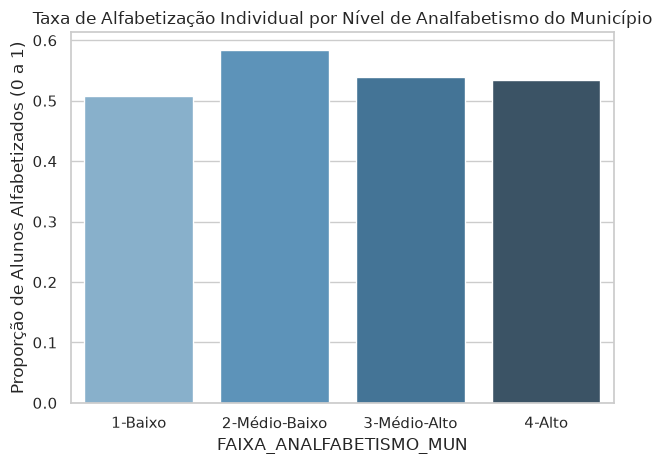

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Supondo que você fez o merge: df_alunos = ts_alunos.merge(df_alunos_municipios, on='ID_MUNICIPIO')

# 2. Criar faixas (quartis) da taxa municipal
df_alunos['FAIXA_ANALFABETISMO_MUN'] = pd.qcut(
    df_alunos['TAXA_ANALFABETISMO_PCT'], 
    q=4, 
    labels=['1-Baixo', '2-Médio-Baixo', '3-Médio-Alto', '4-Alto']
)

# 3. Média de alfabetização por faixa
resumo = df_alunos.groupby('FAIXA_ANALFABETISMO_MUN')['IN_ALFABETIZADO'].agg(
    total_alunos='count',
    taxa_alfabetizados='mean'
).reset_index()

print(resumo)

# 4. Gráfico de barras
sns.barplot(data=resumo, x='FAIXA_ANALFABETISMO_MUN', y='taxa_alfabetizados', palette='Blues_d')
plt.title('Taxa de Alfabetização Individual por Nível de Analfabetismo do Município')
plt.ylabel('Proporção de Alunos Alfabetizados (0 a 1)')
plt.show()


📊 Taxa média de alfabetização individual por Região e Faixa:


FAIXA_ANALFABETISMO_MUN,1-Baixo,2-Médio-Baixo,3-Médio-Alto,4-Alto
REGIAO,,,,
Centro-Oeste,0.514,0.596,NaN,NaN
Nordeste,NaN,NaN,0.577,0.534
Norte,NaN,0.468,0.454,NaN
Sudeste,0.509,0.654,0.617,NaN
Sul,0.499,0.564,NaN,NaN


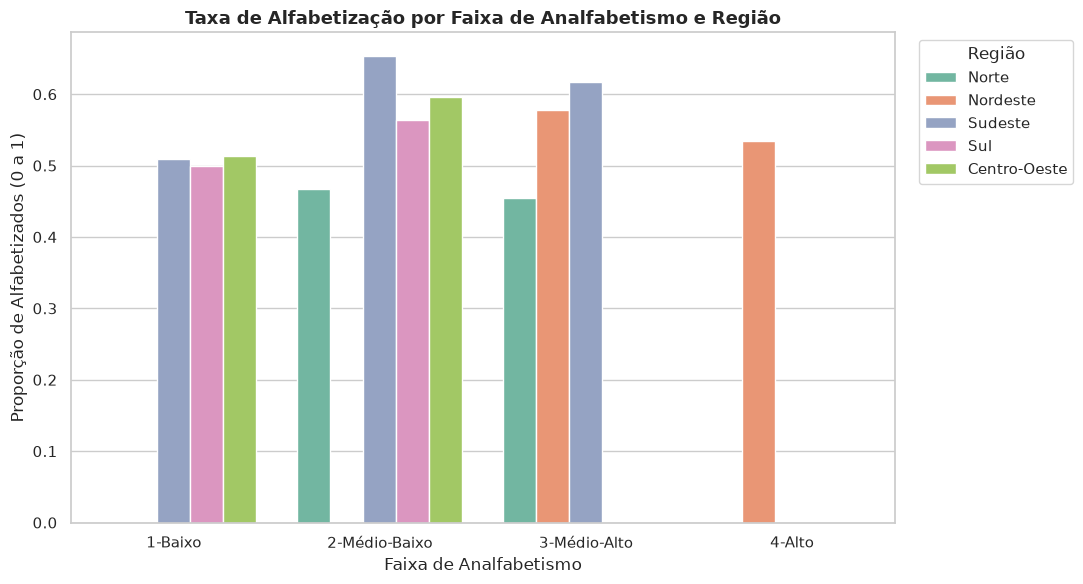

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Localiza a coluna de taxa de analfabetismo dentro de df_alunos
col_taxa = None
for c in ["TAXA_ANALFABETISMO_PCT", "UF_TAXA_ANALFABETISMO_PCT"]:
    if c in df_alunos.columns:
        col_taxa = c
        break

if col_taxa is None:
    raise KeyError(f"Coluna de analfabetismo não encontrada. Colunas disponíveis: {list(df_alunos.columns)}")

# 2. Cria as 4 faixas caso ainda não existam
if "FAIXA_ANALFABETISMO_MUN" not in df_alunos.columns:
    df_alunos["FAIXA_ANALFABETISMO_MUN"] = pd.qcut(
        df_alunos[col_taxa],
        q=4,
        labels=["1-Baixo", "2-Médio-Baixo", "3-Médio-Alto", "4-Alto"]
    )

# 3. Cria a coluna REGIAO se ainda não existir
mapa_regioes = {
    # Norte
    "AM": "Norte", "RR": "Norte", "AP": "Norte", "PA": "Norte",
    "TO": "Norte", "RO": "Norte", "AC": "Norte",
    # Nordeste
    "MA": "Nordeste", "PI": "Nordeste", "CE": "Nordeste", "RN": "Nordeste",
    "PE": "Nordeste", "PB": "Nordeste", "SE": "Nordeste", "AL": "Nordeste", "BA": "Nordeste",
    # Centro-Oeste
    "MT": "Centro-Oeste", "MS": "Centro-Oeste", "GO": "Centro-Oeste", "DF": "Centro-Oeste",
    # Sudeste
    "SP": "Sudeste", "RJ": "Sudeste", "MG": "Sudeste", "ES": "Sudeste",
    # Sul
    "PR": "Sul", "SC": "Sul", "RS": "Sul"
}

if "REGIAO" not in df_alunos.columns:
    if "SG_UF" in df_alunos.columns:
        df_alunos["REGIAO"] = df_alunos["SG_UF"].map(mapa_regioes)
    elif "CO_UF" in df_alunos.columns:
        mapa_co_uf_regiao = {
            11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
            21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste", 27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
            31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
            41: "Sul", 42: "Sul", 43: "Sul",
            50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
        }
        df_alunos["REGIAO"] = df_alunos["CO_UF"].map(mapa_co_uf_regiao)

# 4. Tabela comparativa por Região e Faixa de Analfabetismo
resumo_regiao = (
    df_alunos.groupby(["REGIAO", "FAIXA_ANALFABETISMO_MUN"], observed=False)["IN_ALFABETIZADO"]
    .mean()
    .unstack()
)
print("📊 Taxa média de alfabetização individual por Região e Faixa:")
display(resumo_regiao.round(3))

# 5. Gráfico comparativo
plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_alunos, 
    x="FAIXA_ANALFABETISMO_MUN", 
    y="IN_ALFABETIZADO", 
    hue="REGIAO",
    palette="Set2",
    errorbar=None
)
plt.title("Taxa de Alfabetização por Faixa de Analfabetismo e Região", fontsize=13, weight="bold")
plt.ylabel("Proporção de Alfabetizados (0 a 1)")
plt.xlabel("Faixa de Analfabetismo")
plt.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [46]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'ID_ALUNO', 'ID_ESCOLA',
       'TP_DEPENDENCIA', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026', 'ANO', 'FUN_02_CAT_0', 'COD_RISCO_UF',
       'CATEGORIA_RISCO_UF', 'COD_RISCO_MUNICIPIO',
       'CATEGORIA_RISCO_MUNICIPIO', 'NIVEL_RISCO_DESC_MUNICIPIO',
       'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT',
       'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO',
       'UF_TAXA_FREQ_LIQUIDA_FUND_PCT', 'SG_UF', 'POPULACAO_MIL',
       'TAXA_ANALFABETISMO_PCT', 'RENDIMENTO_MEDIO_MENSAL_REAIS',
       'RENDA_PERCAPITA_SBENEF_MEDIO', 'TAXA_FREQ_LIQUIDA_FUND_PCT', 'REGIAO',
       'META_MUN', 'META_UF', 

In [47]:
df_alunos['CATEGORIA_RISCO_UF'].unique()

<ArrowStringArray>
['Muito alto', nan, 'Moderado', 'Muito baixo', 'Baixo', 'Alto']
Length: 6, dtype: str

In [ ]:
#['NU_ANO_AVALIACAO','CO_UF','TP_DEPENDENCIA','IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','IN_ALFABETIZADO','VL_MEDIA_LP_TOTAL_MUNICIPIO']

['NU_ANO_AVALIACAO',
 'CO_UF',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'IN_ALFABETIZADO',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO']

In [51]:
df_alunos = df_alunos[['NU_ANO_AVALIACAO','CO_UF','TP_DEPENDENCIA','IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','IN_ALFABETIZADO','RENDIMENTO_MEDIO_MENSAL_REAIS','RENDA_PERCAPITA_SBENEF_MEDIO','UF_TAXA_FREQ_LIQUIDA_FUND_PCT','ID_ESCOLA','CO_MUNICIPIO']]

#UF_TAXA_FREQ_LIQUIDA_FUND_PCT
#ID_ESCOLA
#CODIGO_MUNICIPIO

In [ ]:
df_alunos.isna().sum()

NU_ANO_AVALIACAO                   0
CO_UF                              0
TP_DEPENDENCIA                   628
IN_PRESENCA_LP                     0
IN_PREENCHIMENTO_LP                0
IN_ALFABETIZADO                    0
RENDIMENTO_MEDIO_MENSAL_REAIS    628
RENDA_PERCAPITA_SBENEF_MEDIO       0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT    628
ID_ESCOLA                        628
CO_MUNICIPIO                     628
dtype: int64

In [59]:
for col in df_alunos.columns:
    print(f'COLUNA {col}')
    print(df_alunos[col].unique())
    print("-"*30)

COLUNA NU_ANO_AVALIACAO
[2023 2024 2025]
------------------------------
COLUNA CO_UF
[11 13 15 16 17 21 22 23 24 25 26 27 28 29 31 32 33 41 42 43 50 51 52 12
 35 53 14]
------------------------------
COLUNA TP_DEPENDENCIA
[ 3.  2.  4. nan]
------------------------------
COLUNA IN_PRESENCA_LP
[0 1]
------------------------------
COLUNA IN_PREENCHIMENTO_LP
[0 1]
------------------------------
COLUNA IN_ALFABETIZADO
[0 1]
------------------------------
COLUNA RENDIMENTO_MEDIO_MENSAL_REAIS
[2916. 2549. 2407. 3112. 2882. 1907. 2373. 2111. 2418. 2507. 2101. 2099.
 2106. 1966. 3101. 3228. 4032. 3492. 3641. 3485. 3444. 3595. 3264. 2599.
 4036. 5532.   nan 2992. 3667.]
------------------------------
COLUNA RENDA_PERCAPITA_SBENEF_MEDIO
[1524.80115182 1111.49898094 1206.91353936 1474.72654922 1544.32724655
  900.92940594 1250.99606466 1066.69199534 1279.5977724  1265.03894886
 1027.01223555 1034.46917931 1119.89439561 1028.20487168 1905.96192563
 1886.21859337 2347.87883063 2059.90614245 2287.207

In [60]:
df_alunos.shape

(6090791, 11)

In [61]:
df_alunos.dropna(inplace=True)

In [62]:
df_alunos.isna().sum()

NU_ANO_AVALIACAO                 0
CO_UF                            0
TP_DEPENDENCIA                   0
IN_PRESENCA_LP                   0
IN_PREENCHIMENTO_LP              0
IN_ALFABETIZADO                  0
RENDIMENTO_MEDIO_MENSAL_REAIS    0
RENDA_PERCAPITA_SBENEF_MEDIO     0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT    0
ID_ESCOLA                        0
CO_MUNICIPIO                     0
dtype: int64

In [ ]:
import io
import os
 
caminho_s3 = "gold/modelo/tabela_modelo.parquet"

print(f"📦 Convertendo {len(df_alunos):,} linhas para Parquet em memória...")
buffer = io.BytesIO()

df_alunos.to_parquet(
    buffer,
    index=False,
    engine="pyarrow",
    compression="snappy"
)
buffer.seek(0)

tamanho_mb = buffer.getbuffer().nbytes / (1024 * 1024)
print(f"Enviando para s3://{BUCKET}/{caminho_s3} ({tamanho_mb:.2f} MB)...")

 
s3.upload_fileobj(
    Fileobj=buffer,
    Bucket=BUCKET,
    Key=caminho_s3
)

print(" Tabela salva no S3 com sucesso!")


📦 Convertendo 6,090,163 linhas para Parquet em memória...
🚀 Enviando para s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo.parquet (4.83 MB)...
 Tabela salva no S3 com sucesso!


In [ ]:
RFECV 

AutoML
